In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [2]:
from google.colab import files
uploaded = files.upload()

Saving cell2cellholdout.csv to cell2cellholdout.csv


In [3]:
df = pd.read_csv("cell2cellholdout.csv")


In [4]:
features = ["MonthlyRevenue", "MonthlyMinutes", "TotalRecurringCharge",
            "OverageMinutes", "CustomerCareCalls"]


In [5]:
data = df[features].dropna()


In [6]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)


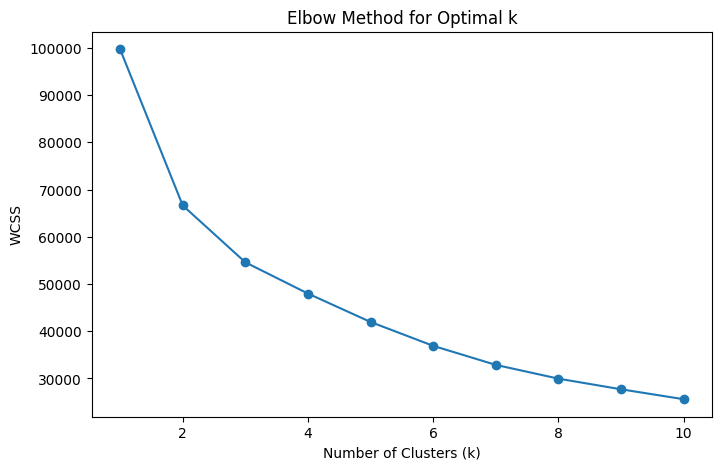

In [7]:
wcss = []  # Within-Cluster Sum of Squares
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()

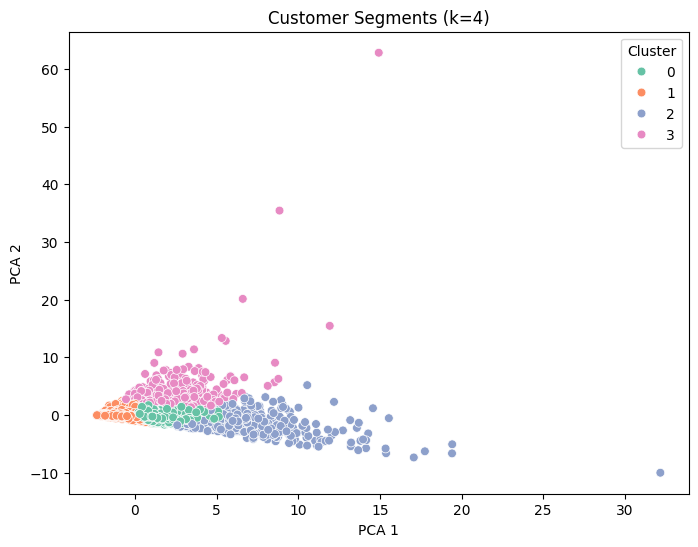

In [8]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels back to the dataset
data["Cluster"] = clusters

# =========================================
# STEP 6: Visualize Clusters (PCA 2D)
# =========================================
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=clusters, palette="Set2", s=40)
plt.title(f"Customer Segments (k={optimal_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()


In [9]:
cluster_summary = data.groupby("Cluster").mean()
print("\n===== Cluster Summary =====")
print(cluster_summary)


===== Cluster Summary =====
         MonthlyRevenue  MonthlyMinutes  TotalRecurringCharge  OverageMinutes  \
Cluster                                                                         
0             87.152370      917.361148             67.156010       62.745172   
1             39.196999      266.135661             36.635135       12.928003   
2            218.517796     1879.638574             82.427877      411.324149   
3             78.727104     1327.965672             58.410448       62.376119   

         CustomerCareCalls  
Cluster                     
0                 2.106188  
1                 0.758529  
2                 3.878444  
3                19.887761  


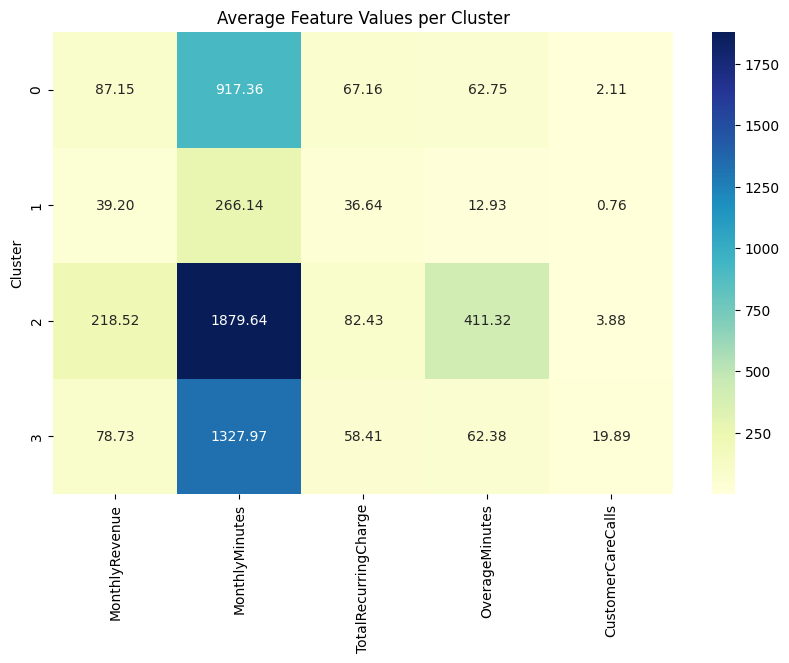

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Average Feature Values per Cluster")
plt.show()

In [11]:
for cluster, row in cluster_summary.iterrows():
    print(f"\n--- Cluster {cluster} ---")
    if row["MonthlyRevenue"] > data["MonthlyRevenue"].mean():
        print("High-spending customers → Recommend premium plans with loyalty rewards.")
    elif row["CustomerCareCalls"] > data["CustomerCareCalls"].mean():
        print("Frequent support callers → Improve service quality, offer proactive support.")
    else:
        print("Low-usage customers → Recommend low-cost plans or special offers.")


--- Cluster 0 ---
High-spending customers → Recommend premium plans with loyalty rewards.

--- Cluster 1 ---
Low-usage customers → Recommend low-cost plans or special offers.

--- Cluster 2 ---
High-spending customers → Recommend premium plans with loyalty rewards.

--- Cluster 3 ---
High-spending customers → Recommend premium plans with loyalty rewards.
